In [6]:
import os
import importlib
import os
from logging import exception

import matplotlib.pyplot as plt
import numpy as np
import sys

from config import db_connection, sys_path, pickle_file
os.environ['TANGOS_DB_CONNECTION'] = db_connection
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)
os.environ['TANGOS_SIMULATION_FOLDER'] = '/home/bk639/data/CDM_z0'
import tangos

sims = tangos.all_simulations()

In [35]:
firebox_sideon_low_x = np.array([0.0006557377049180545, 0.10426229508196726, 0.19999999999999996,
                        0.2990163934426229, 0.4006557377049181, 0.5016393442622951,
                        0.6013114754098358, 0.7009836065573771, 0.8019672131147542,
                        0.901639344262295]) + 0.05

In [36]:
firebox_sideon_low_x

array([0.05065574, 0.1542623 , 0.25      , 0.34901639, 0.45065574,
       0.55163934, 0.65131148, 0.75098361, 0.85196721, 0.95163934])

In [7]:
import time
import pickle
import MCMC_sims
import galaxy_ellipse_collection

# Use one known halo from your data
with open(pickle_file, 'rb') as f:
    ellipse_dict = pickle.load(f)

sim = list(ellipse_dict.keys())[30]
halo_ref = list(ellipse_dict[sim].keys())[0]
halo_data = MCMC_sims.load_and_process_halo_data(pickle_file, sim, halo_ref)


In [5]:
halo_data['x000y090']


array([0.11822234, 0.11822234, 0.11822234])

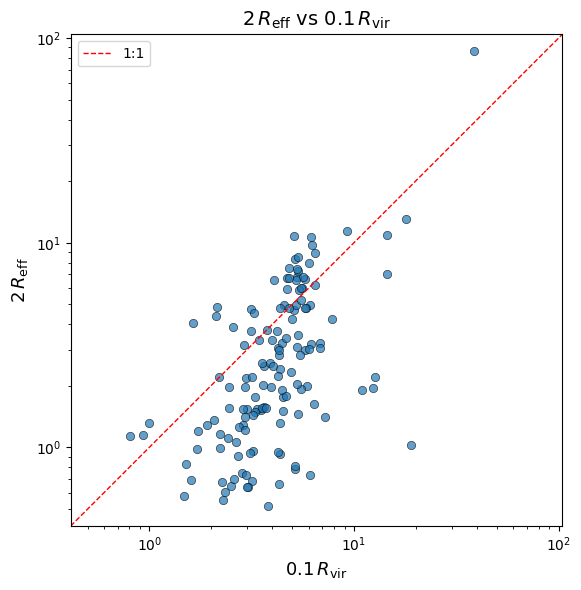

In [8]:
def extract_single_value(value):
    """Extract scalar value from potentially nested data structures"""
    if isinstance(value, list):
        return value[0]
    return float(value)


import matplotlib.pyplot as plt
import numpy as np

rhalf_2_vals = []
Rvir_vals = []

for sim in ellipse_dict.keys():
    for halo_ref in ellipse_dict[sim].keys():
        halo = tangos.get_halo(halo_ref)
        rhalf_2 = halo['Rhalf_v'] * 2
        try:
            Rvir = extract_single_value(halo['Rvir']) * 0.1
        except:
            Rvir = extract_single_value(halo['Rhalo']) * 0.1

        rhalf_2_vals.append(rhalf_2)
        Rvir_vals.append(Rvir)

rhalf_2_vals = np.array(rhalf_2_vals)
Rvir_vals = np.array(Rvir_vals)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(Rvir_vals, rhalf_2_vals, alpha=0.7, edgecolors='k', linewidths=0.5)

# 1:1 reference line
lims = [
    min(Rvir_vals.min(), rhalf_2_vals.min()) * 0.8,
    max(Rvir_vals.max(), rhalf_2_vals.max()) * 1.2,
]
ax.plot(lims, lims, 'r--', lw=1, label='1:1')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'$0.1 \, R_\mathrm{vir}$', fontsize=13)
ax.set_ylabel(r'$2 \, R_\mathrm{eff}$', fontsize=13)
ax.set_title(r'$2\,R_\mathrm{eff}$ vs $0.1\,R_\mathrm{vir}$', fontsize=14)
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [22]:
halo = tangos.get_halo(halo_ref)
reff = halo['image_reffs_v'][0]
halo.calculate('ba_s_smoothed()')(2*reff)

array(0.84155913)

In [ ]:

def calculate_triaxiality(b_over_a: float, c_over_a: float) -> float:
    """
    Calculate triaxiality parameter T_s.

    T_s = (1 - b²/a²) / (1 - c²/a²)
    T_s < 1/3: oblate
    1/3 < T_s < 2/3: triaxial
    T_s > 2/3: prolate
    """
    return (1 - b_over_a ** 2) / (1 - c_over_a ** 2)

def SB_integrated(r_bins, profile_lum_den_v):
    """
    Integrate luminosity density profile to get total luminosity.

    Parameters:
    -----------
    r_bins : array
        Radial bin edges
    profile_lum_den_v : array
        Luminosity density in each bin

    Returns:
    --------
    total_lum : float
        Total integrated luminosity
    """
    # Add 0 at the beginning of r_bins to include the innermost bin
    r_bins_extended = np.insert(r_bins, 0, 0)

    # Calculate annular area for each bin
    # Area of annulus = π * (r_outer² - r_inner²)
    r_inner = r_bins_extended[:-1]
    r_outer = r_bins_extended[1:]

    areas = np.pi * (r_outer ** 2 - r_inner ** 2)

    # remove nans
    nanmask = np.isnan(profile_lum_den_v)
    profile_lum_den_v = profile_lum_den_v[~nanmask]
    areas = areas[~nanmask]

    # Total luminosity = sum of (luminosity density × area)
    total_lum = np.sum(profile_lum_den_v * areas)

    return total_lum

lum_list = []
central_SB = []
reffs = []
mass = []
oblate_mask = []
triaxial_mask = []
prolate_mask = []


i = 0
for sim in sims:
    for halo in sim.timesteps[0].halos[0:10]:
            # Calculate central surface brightness
        if 'profile_mags_v' in halo.keys() and 'profile_binarea_v' in halo.keys():
            mag0 = halo['profile_mags_v'][0][0]
            area0 = halo['profile_binarea_v'][0][0]
            sigma0 = (10 ** (0.4 * (4.8 - mag0))) / area0  # normalize to total lum
            total_lum = SB_integrated(halo['profile_rbins_v'][0], halo['profile_v_lum_den'][0])
            reff = halo['image_reffs_v'][0]
            shape_b_over_a = halo.calculate('ba_s_smoothed()')
            shape_c_over_a = halo.calculate('ca_s_smoothed()')
            mass.append(halo['M_star'])
            ba = shape_b_over_a(2*reff)
            ca = shape_c_over_a(2*reff)
            t = calculate_triaxiality(ba, ca)
            if t < 1/3:
                oblate_mask.append(True)
                triaxial_mask.append(False)
                prolate_mask.append(False)
            elif t > 2/3:
                prolate_mask.append(True)
                triaxial_mask.append(False)
                oblate_mask.append(False)
            elif 1/3 <= t <= 2/3:
                triaxial_mask.append(True)
                oblate_mask.append(False)
                prolate_mask.append(False)
            else:
                triaxial_mask.append(False)
                oblate_mask.append(False)
                prolate_mask.append(False)

            reffs.append(reff)


            central_SB.append(sigma0)
            lum_list.append(total_lum)
            i = i + 1
            print(i)









1


In [36]:
np.shape(sims[0].timesteps[0].halos[0]['isophote_parameters_v_stars'])

(72, 3, 8)

In [51]:
for i in range(3):
    print(1- sims[0].timesteps[0].halos[0]['isophote_parameters_v_stars'][3][i][1])


0.3268999111868497
0.358414453901855
0.38583802614148655


In [52]:
sims[0].timesteps[0].halos[0]['sersic2d_q_v']

array([0.82377269, 0.86065672, 0.56588218, 0.34342696, 0.64330455,
       0.89468205, 0.82376964, 0.86065962, 0.56588264, 0.34343074,
       0.64330761, 0.89467849, 0.72854717, 0.66321832, 0.47557029,
       0.34341166, 0.61841116, 0.88288228, 0.72854398, 0.66321547,
       0.47556807, 0.34340864, 0.61840502, 0.88288138, 0.46496895,
       0.40619771, 0.35146038, 0.34364273, 0.47317605, 0.55546656,
       0.46496564, 0.40619798, 0.35145823, 0.34364394, 0.47317886,
       0.55547041, 0.28175334, 0.27491516, 0.31036329, 0.34343079,
       0.36655082, 0.33619691, 0.28175124, 0.27491488, 0.31036272,
       0.34342798, 0.3665491 , 0.33619517, 0.49910109, 0.46285872,
       0.41347105, 0.34340861, 0.43493316, 0.55736414, 0.49909688,
       0.46285962, 0.4134677 , 0.34340738, 0.43493351, 0.55736842,
       0.75946275, 0.71768007, 0.55876218, 0.34364394, 0.55468576,
       0.8969408 , 0.75945711, 0.71768166, 0.55876136, 0.34363854,
       0.55468437, 0.89694454])

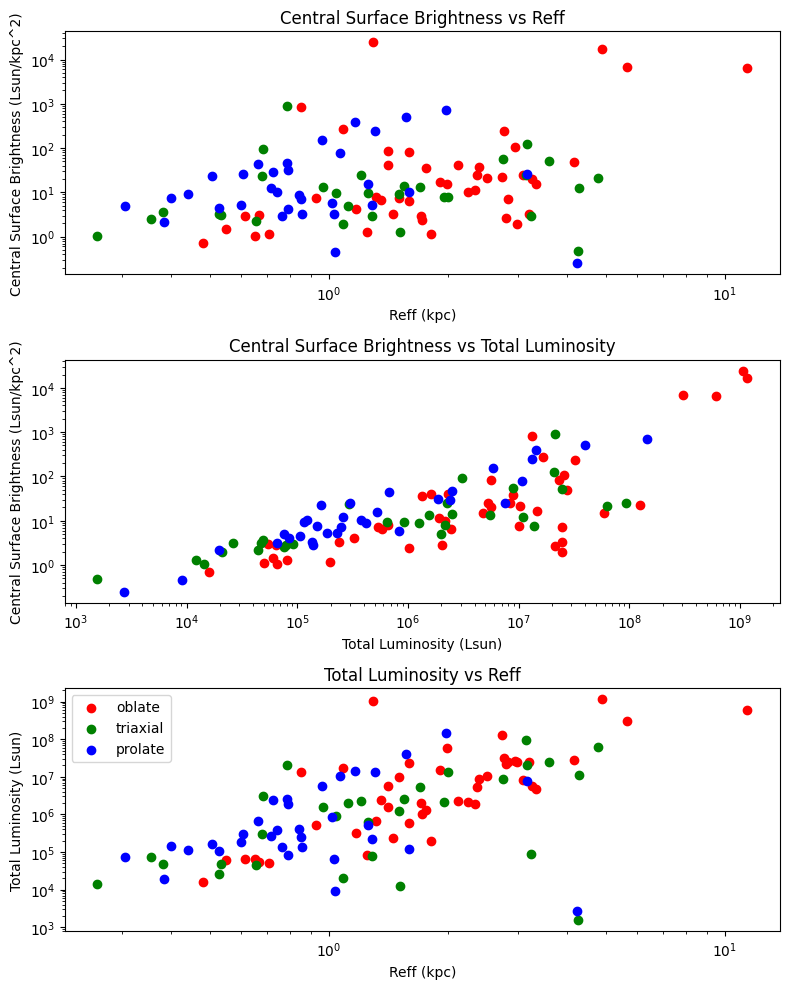

In [6]:
fig,ax = plt.subplots(3,1, figsize=(8,10))
colors = []
reffs = np.array(reffs)
central_SB = np.array(central_SB)
lum_list = np.array(lum_list)
ax[0].scatter(reffs[oblate_mask], central_SB[oblate_mask], c='r', label='oblate')
ax[0].scatter(reffs[triaxial_mask], central_SB[triaxial_mask], c='g', label='triaxial')
ax[0].scatter(reffs[prolate_mask], central_SB[prolate_mask], c='b', label='prolate')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Reff (kpc)')
ax[0].set_ylabel('Central Surface Brightness (Lsun/kpc^2)')
ax[0].set_title('Central Surface Brightness vs Reff')
ax[1].scatter(lum_list[oblate_mask], central_SB[oblate_mask], c='r', label='oblate')
ax[1].scatter(lum_list[triaxial_mask], central_SB[triaxial_mask], c='g', label='triaxial')
ax[1].scatter(lum_list[prolate_mask], central_SB[prolate_mask], c='b', label='prolate')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('Total Luminosity (Lsun)')
ax[1].set_ylabel('Central Surface Brightness (Lsun/kpc^2)')
ax[1].set_title('Central Surface Brightness vs Total Luminosity')


#Plot reff vs lum
ax[2].scatter(reffs[oblate_mask], lum_list[oblate_mask], c='r', label='oblate')
ax[2].scatter(reffs[triaxial_mask], lum_list[triaxial_mask], c='g', label='triaxial')
ax[2].scatter(reffs[prolate_mask], lum_list[prolate_mask], c='b', label='prolate')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Reff (kpc)')
ax[2].set_ylabel('Total Luminosity (Lsun)')
ax[2].set_title('Total Luminosity vs Reff')

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
print(len(lum_list), len(central_SB), len(reffs), len(oblate_mask), len(triaxial_mask), len(prolate_mask))

113 113 113 112 112 112


In [ ]:
plt.scatter(mass, reffs, color=colors)
print(mass, reffs)
plt.xscale('log')
plt.yscale('log')

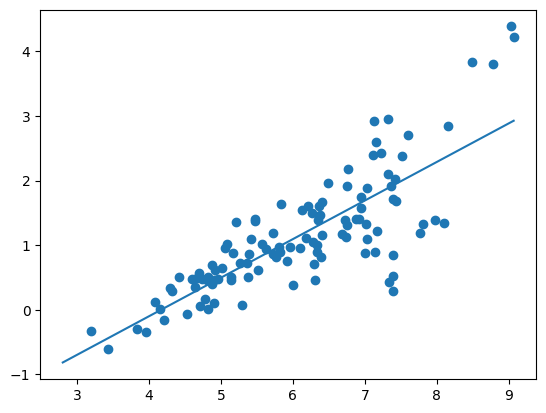

0.5976038394244962 -2.490842667226746 0.8051645206595429 1.029102431772592e-26 0.04196863299835857


In [26]:
 from scipy import stats


x = ((np.array(lum_list)))
y = ((np.array(central_SB)))

x = np.log10(x)
y = np.log10(y)

#sort
sorted_index = np.argsort(x)
x = x[sorted_index]
y = y[sorted_index]

slope, intercept, r, p, se = stats.linregress(x, y,nan_policy='omit')

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel)

# plt.xscale('log')
# plt.yscale('log')
plt.show()

print(slope, intercept, r, p, se)

In [24]:
y

array([           nan, 4.75612876e-01, 2.49033754e-01, 5.08229718e-01,
       4.57667494e-01, 1.30475873e+00, 1.03631592e+00, 7.05917344e-01,
       2.19693839e+00, 1.96345271e+00, 3.17354737e+00, 8.50511424e-01,
       2.99390632e+00, 2.22667899e+00, 3.05875301e+00, 3.68996703e+00,
       1.12647023e+00, 3.03490959e+00, 1.47150539e+00, 2.86162179e+00,
       3.17338277e+00, 1.03861893e+00, 2.54203170e+00, 4.93566310e+00,
       2.90159849e+00, 1.28976318e+00, 4.15915438e+00, 3.00517574e+00,
       4.43925156e+00, 9.12203546e+00, 1.04506996e+01, 3.22604771e+00,
       2.85912927e+00, 7.66289711e+00, 2.30954759e+01, 5.26334041e+00,
       1.17644036e+00, 5.32050002e+00, 3.25763301e+00, 7.24509513e+00,
       1.23105290e+01, 2.38345807e+01, 2.55768234e+01, 4.14238645e+00,
       1.04421747e+01, 8.77905360e+00, 1.56291244e+01, 7.37471109e+00,
       6.48770049e+00, 9.53274509e+00, 7.95043694e+00, 4.35064400e+01,
       5.73308265e+00, 9.51671579e+00, 2.40357875e+00, 9.06540203e+00,
      

In [ ]:
# Standard library imports
import gc
import logging
import multiprocessing as mp
import sys
import traceback
import warnings

# Third-party imports
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import pynbody
from pynbody import array, units
from pynbody.plot.sph import image
import pymp
import scipy
from scipy.interpolate import UnivariateSpline
from scipy.optimize import curve_fit
from skimage.measure import moments, moments_central
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from photutils.aperture import EllipticalAperture
from photutils.isophote import Ellipse, EllipseGeometry, build_ellipse_model

# Local application imports
from tangos.properties import LivePropertyCalculation, LivePropertyCalculationInheritingMetaProperties
from tangos.properties.pynbody import PynbodyPropertyCalculation
from tangos.properties.pynbody.centring import centred_calculation

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger("IsophoteAnalysis")


def myprint(text, clear=False):
    """Custom print function for progress display"""
    import sys
    if clear:
        sys.stdout.write("\r" + " " * 100 + "\r")  # Clear line
    sys.stdout.write(f"\r{text}")
    sys.stdout.flush()


class IsophoteAnalysis(LivePropertyCalculation):
    """Analyzes isophotes to measure projected galaxy shapes at different radii.

    For each projection, we measure ellipticity and position angle at 2-4 Reff
    to track how galaxy shape varies with radius.
    """

    def __init__(self, simulation, image_type='v_stars'):

        print('\ninitializing isophote analysis\n', image_type)

        print('\n names', self.names)
        """Initialize IsophoteAnalysis with specified image type.

        Args:
            simulation: The simulation object
            image_type: Type of images to analyze. Options:
                - 'v_stars': V-band stellar images (default)
                - 'u_stars': U-band stellar images
                - 'i_stars': I-band stellar images
                - 'rho_stars': Mass density stellar images
                - 'rho_dm': Mass density dark matter images
                - 'rho_gas': Mass density gas images
        """
        super().__init__(simulation)
        self.image_type = image_type
        self.visualization_enabled = True  # Set to True to enable visualizations

        self.property_mappings = {
            'v_stars': {
                'images': 'halo_images_v',
                'reffs': 'image_reffs_v',
                'orientations': 'image_orientations_v',
                'rhalf': 'Rhalf_v'
            },
            'u_stars': {
                'images': 'halo_images_u',
                'reffs': 'image_reffs_u_stars',
                'orientations': 'image_orientations_u',
                'rhalf': 'Rhalf_u'
            },
            'i_stars': {
                'images': 'halo_images_i',
                'reffs': 'image_reffs_i_stars',
                'orientations': 'image_orientations_i',
                'rhalf': 'Rhalf_i'
            },
            'rho_stars': {
                'images': 'halo_images_rho_stars',
                'reffs': 'image_reffs_rho_stars',
                'orientations': 'image_orientations_stars',
                'rhalf': 'Rhalf_rho_stars'
            },
            'rho_dm': {
                'images': 'halo_images_rho_dm',
                'reffs': 'image_reffs_rho_dm',
                'orientations': 'image_orientations_dm',
                'rhalf': 'Rhalf_rho_dm'
            },
            'rho_gas': {
                'images': 'halo_images_rho_gas',
                'reffs': 'image_reffs_rho_gas',
                'orientations': 'image_orientations_gas',
                'rhalf': 'Rhalf_rho_gas'
            }
        }
        # Validate image type
        if self.image_type not in self.property_mappings:
            available_types = list(self.property_mappings.keys())
            raise ValueError(f"Unknown image type: {self.image_type}. Available types: {available_types}")

        # Set the names property based on image type
        #self.names = f'isophote_parameters_{self.image_type}'

    def requires_property(self):
        #raise an error if not set ( needs to be overridden in subclasses)
        raise NotImplementedError("Subclasses must implement requires_property() to specify required properties.")

    def check_properties_exist(self, existing_properties):
        """Check if all required properties exist for the specified image type.

        Args:
            existing_properties: Dictionary of existing properties

        Raises:
            ValueError: If required properties are missing
        """
        required_props = self.requires_property()
        missing_props = []

        for prop in required_props:
            if prop not in existing_properties:
                missing_props.append(prop)

        if missing_props:
            raise ValueError(f"Missing required properties for image type '{self.image_type}': {missing_props}")

    @staticmethod
    def estimate_initial_params(image, reff, kpc_per_pixel, plot=False):
        """Estimate ellipse parameters using image moments with visualization"""
        # logger.info("Estimating initial parameters from image moments")

        # Threshold image to separate galaxy from background
        threshold = np.median(image)

        # get binary image of values near the threshold
        binary_image = np.where((image > 5 * threshold) & (image < 20 * threshold), 1, 0)



        # Calculate moments
        m = moments(binary_image)
        # logger.info(f"Zero-order moment (total mass): {m[0, 0]}")

        if m[0, 0] == 0:  # No pixels above threshold
            logger.warning("No pixels above threshold, using image center")
            return image.shape[0] / 2, image.shape[1] / 2, 0.1, 0, 3.0

        # Calculate centroid
        # centroid_y, centroid_x = m[1, 0] / m[0, 0], m[0, 1] / m[0, 0]
        # set centroid to be center of image
        centroid_y, centroid_x = image.shape[0] / 2, image.shape[1] / 2
        # logger.info(f"Centroid: x={centroid_x:.2f}, y={centroid_y:.2f}")

        # Central moments for shape estimation
        mu = moments_central(binary_image, (centroid_y, centroid_x))

        # Covariance matrix
        cov = np.array([[mu[2, 0], mu[1, 1]], [mu[1, 1], mu[0, 2]]]) / mu[0, 0]
        # logger.info(f"Covariance matrix:\n{cov}")

        # Eigenvalues give us axis lengths
        evals, evecs = np.linalg.eig(cov)
        # logger.info(f"Eigenvalues: {evals}")
        # logger.info(f"Eigenvectors:\n{evecs}")

        # Check for negative eigenvalues (numerical instability)
        if np.any(evals <= 0):
            logger.warning("Negative eigenvalues detected, using default values")
            return centroid_x, centroid_y, 0.1, 0, 3.0

        a = np.sqrt(evals[0])  # Major axis
        b = np.sqrt(evals[1])  # Minor axis

        # compute angle
        # logger.info(f"Vector for angle calculation: y={evecs[0, 0]}, x={evecs[0, 1]}")
        angle = np.arctan2(evecs[0, 0], evecs[0, 1])
        # check that a > b
        if a < b:
            # logger.warning("Major axis is smaller than minor axis, swapping values")
            a, b = b, a
            # rotate angle by 90 degrees
            angle += np.pi / 2

        # logger.info(f"Major axis: {a:.2f}, Minor axis: {b:.2f}")

        # Ellipticity and position angle
        eps = 1.0 - (b / a)
        eps = min(0.85, max(0.01, eps))  # Constrain ellipticity
        # logger.info(f"Initial ellipticity: {eps:.2f}")
        # logger.info(f"Initial position angle: {angle:.2f} radians")

        # Estimate a good starting radius from moments
        estimated_radius = np.sqrt(np.mean([mu[2, 0], mu[0, 2]]) / mu[0, 0])
        # Convert to a factor of the effective radius
        radius_factor = estimated_radius / (reff / kpc_per_pixel)
        # Constrain to reasonable values
        radius_factor = min(4.5, max(2.5, radius_factor))
        # logger.info(f"Estimated radius: {estimated_radius:.2f} pixels")
        # logger.info(f"Radius factor (x Reff): {radius_factor:.2f}")



        return centroid_x, centroid_y, eps, angle, radius_factor

    def fit_single_image(self, image_data, radius, step_size_factors, center, eps, pa, sma_factor,
                         kpc_per_pixel, plot=True, apply_smoothing=True, smoothing_kpc=0.1):
        """
        Simplified ellipse fitting with optional image smoothing.

        Args:
            image_data: 2D array of image data
            radius: Effective radius in kpc
            center: Initial center guess (x, y)
            eps: Initial ellipticity guess
            pa: Initial position angle guess
            sma_factor: Initial radius factor for starting SMA
            kpc_per_pixel: Scale conversion
            plot: Whether to visualize results
            apply_smoothing: Whether to apply Gaussian smoothing
            smoothing_kpc: Smoothing scale in kpc (default 0.5 kpc)
        """
        from scipy.ndimage import gaussian_filter
        from scipy.interpolate import interp1d

        # Apply smoothing if requested
        if apply_smoothing:
            # Convert smoothing scale from kpc to pixels
            smoothing_pixels = smoothing_kpc / kpc_per_pixel
            sigma = smoothing_pixels / 2.355  # Convert FWHM to sigma

            # Apply Gaussian smoothing
            image_data = gaussian_filter(image_data, sigma=sigma)
            logger.info(f"Applied Gaussian smoothing with sigma={sigma:.2f} pixels ({smoothing_kpc:.2f} kpc)")

        # Convert radius to pixels
        radius_pixels = radius / kpc_per_pixel

        # Define target radii we want to measure
        target_multipliers = [2.0, 3.0, 4.0]
        target_radii_kpc = {mult: mult * radius for mult in target_multipliers}

        # Set up initial geometry
        geometry = EllipseGeometry(
            x0=center[0],
            y0=center[1],
            sma=sma_factor * radius_pixels,  # Use the initial guess from estimate_initial_params
            eps=eps,
            pa=pa
        )

        # Single ellipse fitting attempt with geometric scaling
        min_sma = 1.0 * radius_pixels  # Start at 1 Reff
        max_sma = 5.0 * radius_pixels  # Go up to 5 Reff
        step = 0.1  # Geometric step factor

        try:
            ellipse = Ellipse(image_data, geometry)
            isolist = ellipse.fit_image(
                minsma=min_sma,
                maxsma=max_sma,
                sma0=geometry.sma,
                linear=False,  # Use geometric scaling
                step=step,     # Geometric factor: sma *= (1 + step)
                maxit=50,      # Reduced iterations for speed
                minit=10,
                fix_center=False,
                fix_eps=False,
                fix_pa=False,
                sclip=3.0,
                nclip=2
            )

            logger.info(f"Fitted {len(isolist.sma)} isophotes from {min_sma:.1f} to {max_sma:.1f} pixels")

        except Exception as e:
            logger.error(f"Ellipse fitting failed: {e}")
            # Return empty result if fitting completely fails
            return [], False

        # Process results
        if len(isolist.sma) == 0:
            logger.warning("No isophotes found")
            return [], False

        # Convert SMA to kpc for easier handling
        smas_kpc = isolist.sma * kpc_per_pixel

        # Filter for good quality fits (gradient error threshold)
        good_mask = isolist.grad_r_error < 0.2  # Slightly relaxed threshold

        if not np.any(good_mask):
            logger.warning("No good quality isophotes found, using all available")
            good_mask = np.ones(len(isolist.sma), dtype=bool)

        # Extract good isophotes
        good_smas_kpc = smas_kpc[good_mask]
        good_eps = isolist.eps[good_mask]
        good_pa = isolist.pa[good_mask]
        good_x0 = isolist.x0[good_mask]
        good_y0 = isolist.y0[good_mask]
        good_intens = isolist.intens[good_mask]
        good_grad_error = isolist.grad_r_error[good_mask]

        # Sort by SMA for interpolation
        sort_idx = np.argsort(good_smas_kpc)
        good_smas_kpc = good_smas_kpc[sort_idx]
        good_eps = good_eps[sort_idx]
        good_pa = good_pa[sort_idx]
        good_x0 = good_x0[sort_idx]
        good_y0 = good_y0[sort_idx]
        good_intens = good_intens[sort_idx]
        good_grad_error = good_grad_error[sort_idx]

        # Interpolate to get values at target radii
        result = []
        targets_met = {mult: False for mult in target_multipliers}

        # Check if we have enough points for interpolation
        if len(good_smas_kpc) >= 2:
            # Create interpolation functions
            try:
                # Use linear interpolation with bounds checking
                f_eps = interp1d(good_smas_kpc, good_eps, kind='linear',
                               bounds_error=False, fill_value='extrapolate')
                f_pa = interp1d(good_smas_kpc, good_pa, kind='linear',
                              bounds_error=False, fill_value='extrapolate')
                f_x0 = interp1d(good_smas_kpc, good_x0, kind='linear',
                              bounds_error=False, fill_value='extrapolate')
                f_y0 = interp1d(good_smas_kpc, good_y0, kind='linear',
                              bounds_error=False, fill_value='extrapolate')

                # For each target radius, either use exact match or interpolate
                for mult in target_multipliers:
                    target_kpc = target_radii_kpc[mult]

                    # Check if target is within our fitted range
                    if good_smas_kpc[0] <= target_kpc <= good_smas_kpc[-1]:
                        # Find closest exact match
                        closest_idx = np.argmin(np.abs(good_smas_kpc - target_kpc))
                        closest_sma_kpc = good_smas_kpc[closest_idx]

                        # If very close, use exact values
                        if abs(closest_sma_kpc - target_kpc) < 0.05 * target_kpc:
                            result.append([
                                closest_sma_kpc / kpc_per_pixel,  # Convert back to pixels
                                good_eps[closest_idx],
                                good_pa[closest_idx],
                                good_grad_error[closest_idx],
                                good_x0[closest_idx],
                                good_y0[closest_idx],
                                good_intens[closest_idx],
                                0.0  # RMS placeholder
                            ])
                            targets_met[mult] = True
                            logger.info(f"Target {mult}×Reff: exact match at {closest_sma_kpc:.2f} kpc")
                        else:
                            # Interpolate
                            interp_eps = float(f_eps(target_kpc))
                            interp_pa = float(f_pa(target_kpc))
                            interp_x0 = float(f_x0(target_kpc))
                            interp_y0 = float(f_y0(target_kpc))

                            result.append([
                                target_kpc / kpc_per_pixel,  # Convert to pixels
                                interp_eps,
                                interp_pa,
                                0.1,  # Estimated grad error for interpolated values
                                interp_x0,
                                interp_y0,
                                0.0,  # Intensity placeholder
                                0.0   # RMS placeholder
                            ])
                            targets_met[mult] = True
                            logger.info(f"Target {mult}×Reff: interpolated at {target_kpc:.2f} kpc")
                    else:
                        logger.warning(f"Target {mult}×Reff ({target_kpc:.2f} kpc) outside fitted range "
                                     f"[{good_smas_kpc[0]:.2f}, {good_smas_kpc[-1]:.2f}]")

            except Exception as e:
                logger.error(f"Interpolation failed: {e}")

        # If we couldn't interpolate, at least return the closest matches we have
        if not result and len(good_smas_kpc) > 0:
            logger.warning("Could not interpolate; returning closest available isophotes")
            for mult in target_multipliers:
                target_kpc = target_radii_kpc[mult]
                closest_idx = np.argmin(np.abs(good_smas_kpc - target_kpc))

                result.append([
                    good_smas_kpc[closest_idx] / kpc_per_pixel,
                    good_eps[closest_idx],
                    good_pa[closest_idx],
                    good_grad_error[closest_idx],
                    good_x0[closest_idx],
                    good_y0[closest_idx],
                    good_intens[closest_idx],
                    0.0
                ])

        # # Visualization if requested
        # if plot:
        self.visualize_simple_results(image_data, isolist, good_mask,
                                     target_radii_kpc, result, kpc_per_pixel,
                                     apply_smoothing, smoothing_kpc)

        return result, all(targets_met.values())


    def visualize_simple_results(self, image_data, isolist, good_mask,
                                target_radii_kpc, result, kpc_per_pixel,
                                smoothing_applied, smoothing_kpc):
        """Simplified visualization for debugging"""
        plt.figure(figsize=(15, 5))

        # Plot 1: Image with fitted ellipses
        plt.subplot(1, 3, 1)
        plt.imshow(np.log10(image_data + 1e-10), origin='lower', cmap='viridis')

        #extract sma, eps, pa, x0, y0 from isophote_paramaters

        # Draw good quality ellipses
        from matplotlib.patches import Ellipse as MplEllipse
        for i, is_good in enumerate(good_mask):
            if is_good:
                sma = isolist.sma[i]
                b = sma * (1 - isolist.eps[i])
                ell = MplEllipse((isolist.x0[i], isolist.y0[i]),
                                width=2*sma, height=2*b,
                                angle=np.degrees(isolist.pa[i]),
                                edgecolor='yellow', facecolor='none',
                                linewidth=1, alpha=0.5)
                plt.gca().add_patch(ell)

        # Draw target ellipses from results
        for i, (mult, target_kpc) in enumerate(target_radii_kpc.items()):
            if i < len(result):
                sma_pix = result[i][0]
                b = sma_pix * (1 - result[i][1])
                color = ['red', 'green', 'blue'][i]
                ell = MplEllipse((result[i][4], result[i][5]),
                                width=2*sma_pix, height=2*b,
                                angle=np.degrees(result[i][2]),
                                edgecolor=color, facecolor='none',
                                linewidth=2, label=f'{mult}×Reff')
                plt.gca().add_patch(ell)

        plt.legend()
        title = f'Fitted Ellipses'
        if smoothing_applied:
            title += f' (smoothed: {smoothing_kpc:.2f} kpc)'
        plt.title(title)

        # Plot 2: Ellipticity profile
        plt.subplot(1, 3, 2)
        smas_kpc = isolist.sma * kpc_per_pixel
        plt.plot(smas_kpc[good_mask], isolist.eps[good_mask], 'o-', label='Good fits')
        plt.plot(smas_kpc[~good_mask], isolist.eps[~good_mask], 'x', alpha=0.3, label='Poor fits')

        # Mark targets
        for i, (mult, target_kpc) in enumerate(target_radii_kpc.items()):
            if i < len(result):
                plt.plot(target_kpc, result[i][1], 'o', markersize=10,
                        color=['red', 'green', 'blue'][i], label=f'{mult}×Reff')

        plt.xlabel('SMA (kpc)')
        plt.ylabel('Ellipticity')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 3: Gradient error
        plt.subplot(1, 3, 3)
        plt.semilogy(smas_kpc, isolist.grad_r_error, 'o-')
        plt.axhline(y=0.2, color='r', linestyle='--', label='Quality threshold')
        plt.xlabel('SMA (kpc)')
        plt.ylabel('Gradient Error')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()



    def get_isophote(self, existing_properties):
        """
        Fit elliptical isophotes to galaxy images using moment-based initialization.

        Args:
            existing_properties: Dictionary containing required properties based on image_type

        Returns:
            List of isophote parameters for each orientation
        """
        print(f'\tGenerating isophotes for {self.image_type}...\n')
        # Check that all required properties exist
        self.check_properties_exist(existing_properties)

        # Get the property mappings for this image type
        mapping = self.property_mappings[self.image_type]

        # Extract the required properties using the mappings
        images = existing_properties[mapping['images']]
        reff_values = existing_properties[mapping['reffs']]
        orientations = existing_properties[mapping['orientations']]
        Rhalf = existing_properties[mapping['rhalf']]

        # Step size factors ordered from largest to smallest
        step_size_factors = [1.0, 0.5, 0.25, 0.125]

        # Calculate kpc per pixel scale
        kpc_per_pixel = (9 * Rhalf) / images[0].shape[0]
        # logger.info(f"kpc_per_pixel scale: {kpc_per_pixel:.4f}")

        # Check if we should use parallel processing
        n_cores = min(40, len(images))  # Use at most 40 cores or number of images (should always be 72, unless we are testing
        n_cores = 1

        params = pymp.shared.dict()
        prog = pymp.shared.array((1,), dtype=int)
        prog[0] = 0

        # Precompute initial estimates to avoid recalculation in parallel processing
        initial_params = []
        for k, img in enumerate(images):
            try:
                # Only visualize the first image if visualization is enabled
                plot_this_image = self.visualization_enabled and k == 70

                center_x, center_y, initial_eps, initial_pa, radius_factor = self.estimate_initial_params(
                    img, reff_values[k], kpc_per_pixel, plot=plot_this_image)

                initial_params.append((center_x, center_y, initial_eps, initial_pa, radius_factor))

            except Exception as e:
                logger.error(f"Error estimating initial parameters for image {k}: {e}")
                traceback.print_exc()
                raise


        print(f'\tGenerating isophotes for {self.image_type}: {round(prog[0] / len(images) * 100, 2)}%')
        with pymp.Parallel(n_cores) as p:
            for k in p.range(0, len(images)):
                try:
                    image_data = images[k]
                    radius = reff_values[k]
                    orientation = orientations[k]

                    # Get precomputed initial parameters
                    center_x, center_y, initial_eps, initial_pa, radius_factor = initial_params[k]
                    center = (center_x, center_y)

                    # Fit isophotes with iterative refinement
                    param_i, all_targets_met = self.fit_single_image(image_data, radius, step_size_factors,
                                                                     center, initial_eps, initial_pa, radius_factor,
                                                                     kpc_per_pixel,
                                                                     plot=self.visualization_enabled and k == 39)

                    # Log success or warning
                    # if all_targets_met:
                    #     logger.info(f"Successfully fit all target radii for orientation {orientation}")
                    # else:
                    #     logger.warning(f"Could not fit all target radii for orientation {orientation}")

                except Exception as e:
                    print(f'Error in orientation {orientation}: {e}')
                    traceback.print_exc()
                    logger.error(f'Error in orientation {orientation}: {e}')
                    raise

                with p.lock:
                    params[orientation] = param_i
                prog[0] += 1
                myprint(f'\tGenerating isophotes for {self.image_type}: {round(prog[0] / (len(images)) * 100, 2)}%',
                        clear=True)


        params_dict = dict(params)

        # Sort by orientation
        params_sorted = dict(sorted(params_dict.items()))



        # Unpack results from sorted dictionary
        isophote_parameters = [params_sorted[key] for key in params_sorted]



        return isophote_parameters

    def live_calculate(self, existing_properties):
        """Main calculation method required by tangos"""
        print(f'Calculating isophotes for {self.image_type}...')
        logger.info(f'Calculating isophotes for {self.image_type}...')
        return self.get_isophote(existing_properties)

In [ ]:
 
class VBandIsophoteAnalysis(IsophoteAnalysis):
    """V-band isophote analysis (default)"""
    names = 'isophote_parameters_v_stars'

    def requires_property(self):
        return  ['halo_images_v','image_reffs_v', 'image_orientations_v', 'Rhalf_v']

    def __init__(self, simulation):
        super().__init__(simulation, image_type='v_stars')

iso = VBandIsophoteAnalysis(simulation=halo)
isophote_params = iso.live_calculate(halo)



In [ ]:
for isophote_param, orientation in zip(isophote_params, halo['image_orientations_v']):
    print(f'orientation: {orientation}')
    for param in isophote_param:
        print(f'sma: {param[0]:.2f} kpc, eps: {param[1]:.2f}, pa: {np.degrees(param[2]):.2f} degrees, '
              f'grad_error: {param[3]:.2f}, x0: {param[4]:.2f}, y0: {param[5]:.2f}, intensity: {param[6]:.2f}, rms: {param[7]:.2f}')

In [ ]:
iso.vi

In [ ]:
x = [2]

In [ ]:
x

In [ ]:
x[0]

In [8]:
car = {
  "brand": "Ford",
  "model": "Mustang",
  "year": 1964
}

car.update({"color": "White"})

print(car)

{'color': 'White'}
